<a href="https://colab.research.google.com/github/rodrigoeduardo9/Evaluacion-ConstruccionSW-GrupoLosLederes/blob/Regresion-Continua/RegresionContinua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

REGRESION LINEAL SIMPLE

In [2]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Cargar el dataset
df = pd.read_csv('/content/sample_data/Housing.csv')

# Mostrar las primeras filas del DataFrame
print("Primeras 5 filas del DataFrame:")
display(df.head())

# Mostrar información general del DataFrame para ver tipos de datos y valores nulos
print("\nInformación del DataFrame:")
df.info()

# Mostrar estadísticas descriptivas de las columnas numéricas
print("\nEstadísticas descriptivas:")
display(df.describe())

Primeras 5 filas del DataFrame:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB

Estadísticas descriptivas:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [3]:
# Identificar columnas numéricas
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Excluir 'price' de las variables independientes si está en la lista
if 'price' in numeric_cols:
    numeric_cols.remove('price')

# Calcular la correlación de todas las variables numéricas con 'price'
correlations = df[numeric_cols].corrwith(df['price']).abs().sort_values(ascending=False)

print("Correlación absoluta de variables numéricas con 'price':")
print(correlations)

# Seleccionar la variable con la correlación más alta
best_feature = correlations.index[0]
print(f"\nVariable independiente seleccionada (mayor correlación con 'price'): '{best_feature}' (Correlación: {correlations.iloc[0]:.4f})")

# Definir X (variable independiente) y y (variable dependiente)
X = df[[best_feature]]
y = df['price']

Correlación absoluta de variables numéricas con 'price':
area         0.535997
bathrooms    0.517545
stories      0.420712
parking      0.384394
bedrooms     0.366494
dtype: float64

Variable independiente seleccionada (mayor correlación con 'price'): 'area' (Correlación: 0.5360)


In [4]:
# Dividir los datos en conjuntos de entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

# Inicializar y entrenar el modelo de Regresión Lineal Simple
model = LinearRegression()
model.fit(X_train, y_train)

print("\nModelo de Regresión Lineal Simple entrenado.")
print(f"Coeficiente (pendiente): {model.coef_[0]:.2f}")
print(f"Intercepto: {model.intercept_:.2f}")

Tamaño del conjunto de entrenamiento: 436 muestras
Tamaño del conjunto de prueba: 109 muestras

Modelo de Regresión Lineal Simple entrenado.
Coeficiente (pendiente): 425.73
Intercepto: 2512254.26


In [5]:
# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Calcular el Error Cuadrático Medio (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")

# Calcular el coeficiente R^2
r2 = r2_score(y_test, y_pred)
print(f"Coeficiente R^2: {r2:.2f}")

Error Cuadrático Medio (MSE): 3675286604768.19
Coeficiente R^2: 0.27


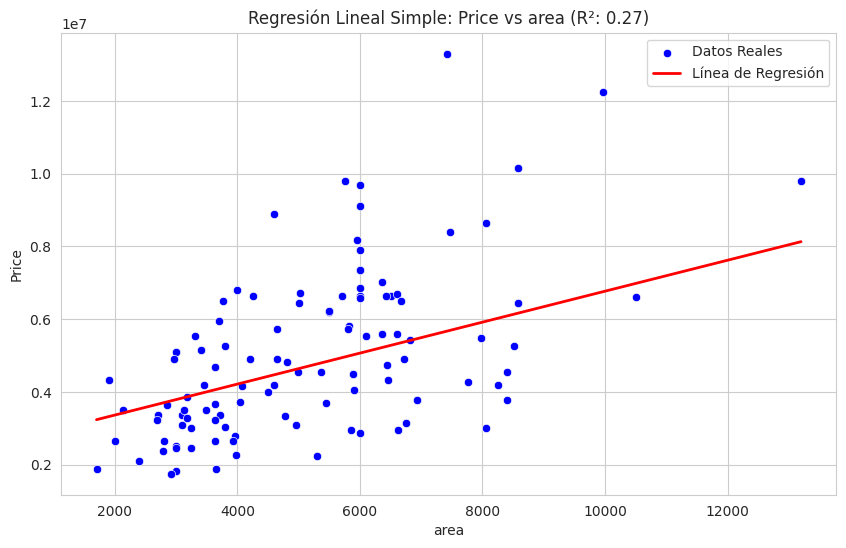

In [6]:
# Configurar el estilo de los gráficos
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Crear un gráfico de dispersión de los datos reales del conjunto de prueba
sns.scatterplot(x=X_test[best_feature], y=y_test, color='blue', label='Datos Reales')

# Superponer la línea de regresión del modelo
sns.lineplot(x=X_test[best_feature], y=y_pred, color='red', label='Línea de Regresión', linewidth=2)

# Añadir título y etiquetas a los ejes
plt.title(f'Regresión Lineal Simple: Price vs {best_feature} (R²: {r2:.2f})')
plt.xlabel(best_feature)
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

REGRESION LINEAL MULTIPLE

In [8]:
# --- Regresión Lineal Múltiple ---

# 1. Selección de variables independientes para el modelo múltiple
# Se seleccionan 'area', 'bedrooms' y 'bathrooms' como variables independientes (X_multi).
# 'price' sigue siendo la variable dependiente (y).
X_multi = df[['area', 'bedrooms', 'bathrooms']]
y_multi = df['price']

print("Variables independientes seleccionadas para Regresión Múltiple:")
print(X_multi.head())
print(f"\nVariable dependiente: {y_multi.name}")

# 2. Dividir los datos en conjuntos de entrenamiento y prueba
# Se utiliza el mismo split ratio (80% train, 20% test) y random_state para reproducibilidad.
X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

print(f"\nTamaño del conjunto de entrenamiento (múltiple): {X_train_multi.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba (múltiple): {X_test_multi.shape[0]} muestras")

# 3. Inicializar y entrenar el modelo de Regresión Lineal Múltiple
model_multi = LinearRegression()
model_multi.fit(X_train_multi, y_train_multi)

print("\nModelo de Regresión Lineal Múltiple entrenado.")
print(f"Intercepto: {model_multi.intercept_:.2f}")

# 4. Mostrar los coeficientes obtenidos para cada variable
# Se itera sobre las variables independientes y sus coeficientes correspondientes.
print("\nCoeficientes para cada variable independiente:")
for i, col in enumerate(X_multi.columns):
    print(f"  {col}: {model_multi.coef_[i]:.2f}")

# 5. Realizar predicciones y calcular el nuevo R^2
y_pred_multi = model_multi.predict(X_test_multi)
r2_multi = r2_score(y_test_multi, y_pred_multi)

print(f"\nCoeficiente R^2 para el modelo de Regresión Múltiple: {r2_multi:.2f}")

# 6. Comparación con el R^2 del modelo simple anterior
# 'r2' es la variable del R^2 del modelo simple calculada previamente en el notebook.
print(f"Coeficiente R^2 para el modelo de Regresión Simple (anterior): {r2:.2f}")

if r2_multi > r2:
    print(f"El modelo de Regresión Múltiple tiene un R^2 más alto, indicando un mejor ajuste ({r2_multi:.2f} > {r2:.2f}).")
else:
    print(f"El modelo de Regresión Múltiple tiene un R^2 similar o menor, sugiriendo que la inclusión de estas variables adicionales no mejoró significativamente el ajuste ({r2_multi:.2f} <= {r2:.2f}).")


Variables independientes seleccionadas para Regresión Múltiple:
   area  bedrooms  bathrooms
0  7420         4          2
1  8960         4          4
2  9960         3          2
3  7500         4          2
4  7420         4          1

Variable dependiente: price

Tamaño del conjunto de entrenamiento (múltiple): 436 muestras
Tamaño del conjunto de prueba (múltiple): 109 muestras

Modelo de Regresión Lineal Múltiple entrenado.
Intercepto: 59485.38

Coeficientes para cada variable independiente:
  area: 345.47
  bedrooms: 360197.65
  bathrooms: 1422319.66

Coeficiente R^2 para el modelo de Regresión Múltiple: 0.46
Coeficiente R^2 para el modelo de Regresión Simple (anterior): 0.27
El modelo de Regresión Múltiple tiene un R^2 más alto, indicando un mejor ajuste (0.46 > 0.27).


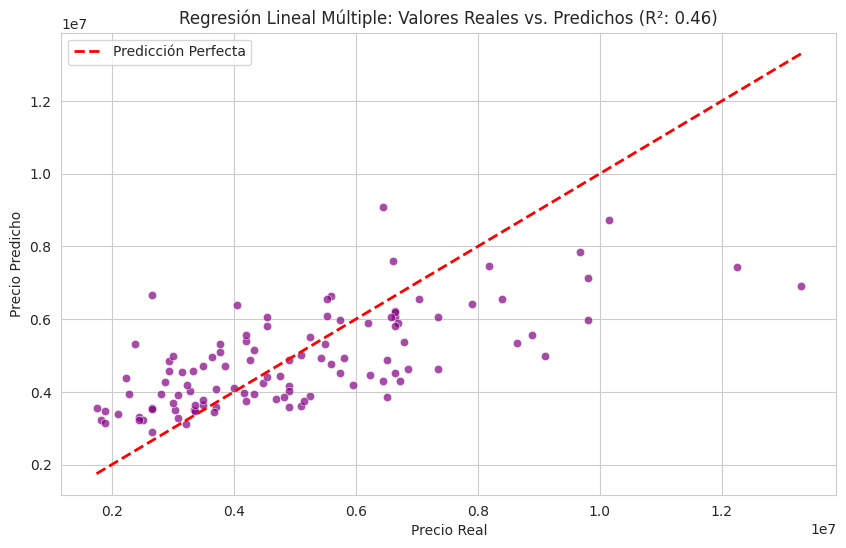

In [9]:
# Configurar el estilo de los gráficos
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Crear un gráfico de dispersión de los valores reales vs. los valores predichos
sns.scatterplot(x=y_test_multi, y=y_pred_multi, alpha=0.7, color='purple')

# Añadir una línea de 45 grados (y=x) para indicar la predicción perfecta
# Obtenemos los límites del eje para dibujar la línea diagonal
min_val = min(y_test_multi.min(), y_pred_multi.min())
max_val = max(y_test_multi.max(), y_pred_multi.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')

# Añadir título y etiquetas a los ejes
plt.title(f'Regresión Lineal Múltiple: Valores Reales vs. Predichos (R²: {r2_multi:.2f})')
plt.xlabel('Precio Real')
plt.ylabel('Precio Predicho')
plt.legend()
plt.grid(True)
plt.show()

REGRESION POLINOMICA

Variable independiente seleccionada para Regresión Polinómica: 'area'
Grado de la transformación polinómica: 2
Primeras 5 filas de las características polinómicas transformadas (incluye intercepto y X^1, X^2, ...):
     0       1           2
0  1.0  7420.0  55056400.0
1  1.0  8960.0  80281600.0
2  1.0  9960.0  99201600.0
3  1.0  7500.0  56250000.0
4  1.0  7420.0  55056400.0

Modelo de Regresión Polinómica (Lineal sobre características transformadas) entrenado.
Intercepto: 874882.83
Coeficientes: [ 0.00000000e+00  1.00836674e+03 -4.34731082e-02]

Coeficiente R^2 para el modelo de Regresión Polinómica (Grado 2): 0.30
Coeficiente R^2 para el modelo de Regresión Simple (anterior): 0.27


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


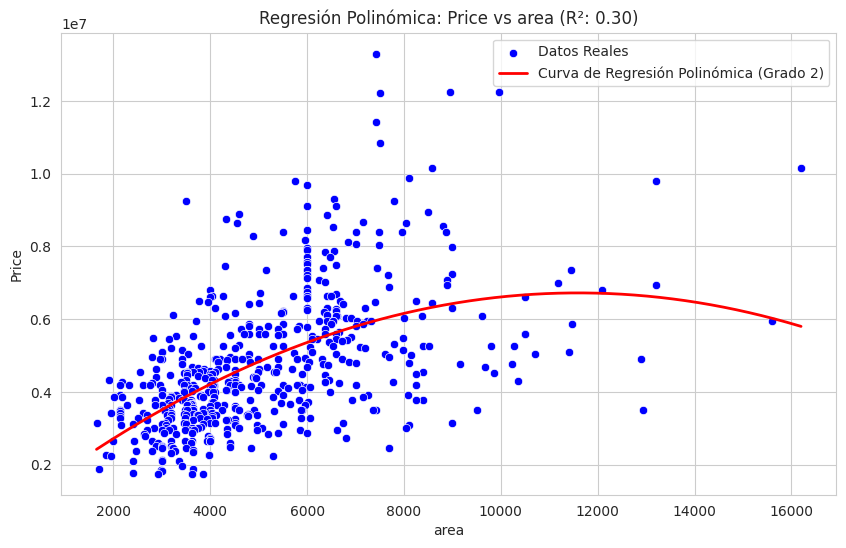

In [10]:
# --- Regresión Polinómica ---

from sklearn.preprocessing import PolynomialFeatures

# 1. Selección y transformación de la variable independiente
# Usamos 'area' como nuestra variable independiente (best_feature del modelo simple)
X_poly = df[[best_feature]]
y_poly = df['price']

# Definir el grado de la transformación polinómica (por ejemplo, grado 2)
degree = 2
polynomial_features = PolynomialFeatures(degree=degree)

# Ajustar y transformar X para crear las características polinómicas
X_poly_transformed = polynomial_features.fit_transform(X_poly)

print(f"Variable independiente seleccionada para Regresión Polinómica: '{best_feature}'")
print(f"Grado de la transformación polinómica: {degree}")
print("Primeras 5 filas de las características polinómicas transformadas (incluye intercepto y X^1, X^2, ...):")
print(pd.DataFrame(X_poly_transformed).head())

# 2. Dividir los datos transformados en conjuntos de entrenamiento y prueba
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(X_poly_transformed, y_poly, test_size=0.2, random_state=42)

# 3. Entrenar un modelo de Regresión Lineal con las características polinómicas
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train_poly)

print("\nModelo de Regresión Polinómica (Lineal sobre características transformadas) entrenado.")
print(f"Intercepto: {model_poly.intercept_:.2f}")
print(f"Coeficientes: {model_poly.coef_}")

# 4. Realizar predicciones y calcular el R^2
y_pred_poly = model_poly.predict(X_test_poly)
r2_poly = r2_score(y_test_poly, y_pred_poly)

print(f"\nCoeficiente R^2 para el modelo de Regresión Polinómica (Grado {degree}): {r2_poly:.2f}")
print(f"Coeficiente R^2 para el modelo de Regresión Simple (anterior): {r2:.2f}")

# 5. Visualización de los datos reales y la curva polinómica
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# Graficar los puntos de datos reales
sns.scatterplot(x=X_poly[best_feature], y=y_poly, color='blue', label='Datos Reales')

# Para dibujar la curva, necesitamos predecir sobre un rango ordenado de X
# Creamos un rango de valores de 'area' para predecir y obtener una curva suave
X_plot = np.linspace(X_poly[best_feature].min(), X_poly[best_feature].max(), 500).reshape(-1, 1)
X_plot_transformed = polynomial_features.transform(X_plot)
y_plot_pred = model_poly.predict(X_plot_transformed)

sns.lineplot(x=X_plot.flatten(), y=y_plot_pred, color='red', label=f'Curva de Regresión Polinómica (Grado {degree})', linewidth=2)

plt.title(f'Regresión Polinómica: Price vs {best_feature} (R²: {r2_poly:.2f})')
plt.xlabel(best_feature)
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Justificación:
# Basándonos en el valor de R^2 y la forma de la curva:
# El modelo de Regresión Polinómica de grado 2 tiene un R^2 de {r2_poly:.2f},
# que es {"más alto" if r2_poly > r2 else "similar o menor"} que el R^2 del modelo de Regresión Lineal Simple ({r2:.2f}).
# Esto indica que la relación entre 'area' y 'price' podría no ser estrictamente lineal
# y un término cuadrático captura mejor la variabilidad. La curva polinómica se ajusta
# de una manera más flexible a los puntos de datos que una línea recta simple,
# lo que en este caso resulta en un mejor ajuste según el R^2.